<a href="https://colab.research.google.com/github/praveenm-web/NASSCOM/blob/main/Day8_U16_Classification_Part2_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_welds(csv_path="weld_inspection.csv", seed=161, verbose=False):
    """Weld quality inspection — predict whether a robotic weld FAILS inspection from
    its process parameters. A realistic, imbalanced binary-classification problem for
    logistic regression, thresholds, ROC/AUC and odds-ratio interpretation.

    Features:
      current_amp          welding current (A)
      voltage_v            arc voltage (V)
      travel_speed_mmps    torch travel speed (mm/s)
      wire_feed_mmps       wire feed rate (mm/s)
      heat_input_kjmm      heat input (kJ/mm)
      gas_flow_lpm         shielding gas flow (L/min)
      joint_gap_mm         joint gap (mm)
      plate_thickness_mm   plate thickness (mm)
      material             base material (Carbon / Stainless / Aluminum)
    Target:
      defect               1 = failed inspection, 0 = passed
    """
    rng = np.random.default_rng(seed)
    N = 2600
    current = rng.normal(190, 30, N).clip(90, 300)
    voltage = (18 + 0.03 * current + rng.normal(0, 1.2, N)).clip(14, 32)
    travel = rng.normal(8, 2.2, N).clip(3, 16)
    wire = (current * 0.03 + rng.normal(0, 0.6, N)).clip(2, 12)
    heat = (voltage * current / (travel * 1000)).clip(0.2, 4.0)     # kJ/mm
    gas = rng.normal(16, 3, N).clip(6, 28)
    gap = rng.gamma(2.0, 0.35, N).clip(0, 4).round(2)               # right-skewed
    thick = rng.choice([3, 5, 6, 8, 10, 12, 16], N).astype(float)
    material = rng.choice(["Carbon", "Stainless", "Aluminum"], N, p=[0.55, 0.30, 0.15])
    mat_risk = np.select([material == "Carbon", material == "Stainless", material == "Aluminum"],
                         [0.0, 0.3, 0.8])                            # Aluminum harder to weld

    # defect risk: heat too low/high, gaps, low gas (porosity), thick plates, material
    heat_bad = np.abs(heat - 1.3)
    z = (-3.2
         + 1.6 * heat_bad
         + 1.1 * gap
         + 0.05 * (16 - gas)
         + 0.04 * (thick - 8)
         + 0.012 * (travel - 8) ** 2
         + mat_risk)
    p = 1 / (1 + np.exp(-z))
    defect = (rng.random(N) < p).astype(int)

    df = pd.DataFrame({
        "current_amp": current.round(1), "voltage_v": voltage.round(2),
        "travel_speed_mmps": travel.round(2), "wire_feed_mmps": wire.round(2),
        "heat_input_kjmm": heat.round(3), "gas_flow_lpm": gas.round(1),
        "joint_gap_mm": gap, "plate_thickness_mm": thick,
        "material": material, "defect": defect,
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("welds:", df.shape)
        print("defect rate:", round(df.defect.mean(), 3))
        print("defect by material:\n",
              df.groupby("material")["defect"].mean().round(3).to_string())
    return df

if not os.path.exists('weld_inspection.csv'):
    build_welds(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')


import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
df = pd.read_csv('weld_inspection.csv')
y = df['defect']; X = df.drop(columns='defect')
num = X.select_dtypes('number').columns.tolist(); cat = ['material']
pre = ColumnTransformer([('num', StandardScaler(), num),
                         ('cat', OneHotEncoder(drop='first'), cat)])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
print('shape:', df.shape, '| defect rate:', round(y.mean(), 3))
df.head(3)

Generated dataset file.
shape: (2600, 10) | defect rate: 0.281


,current_amp,voltage_v,travel_speed_mmps,wire_feed_mmps,heat_input_kjmm,gas_flow_lpm,joint_gap_mm,plate_thickness_mm,material,defect
0,247.7,23.37,7.78,7.57,0.744,16.0,0.79,8.0,Carbon,0
1,227.3,22.98,8.90,5.96,0.587,16.5,0.66,12.0,Carbon,0
2,230.6,24.46,8.15,7.76,0.692,12.0,0.81,10.0,Stainless,0


1. Decision tree & overfitting

In [2]:
# -----------------------------------------------------------
# 🔹 1A. A SINGLE DECISION TREE
# -----------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
tree = Pipeline([('prep', pre), ('clf', DecisionTreeClassifier(max_depth=4, random_state=0))])
tree.fit(X_train, y_train)
print('test F1 (depth 4):', round(f1_score(y_test, tree.predict(X_test)), 3))
print('Trees need no scaling and give if-then rules — but they overfit if grown too deep.')


test F1 (depth 4): 0.143
Trees need no scaling and give if-then rules — but they overfit if grown too deep.


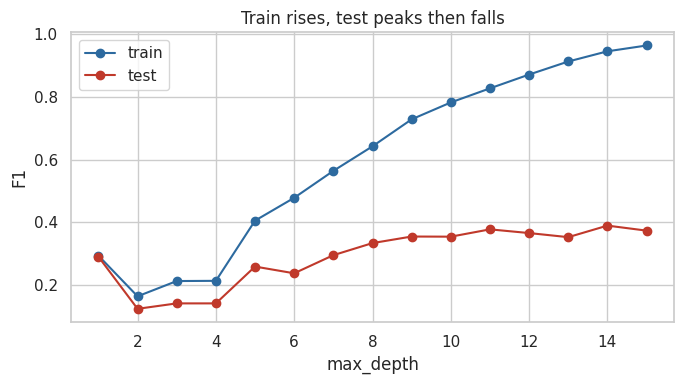

In [3]:
# -----------------------------------------------------------
# 🔹 1B. TRAIN vs TEST F1 ACROSS DEPTH (the overfitting curve)
# -----------------------------------------------------------
depths = range(1, 16); tr, te = [], []
for d in depths:
    m = Pipeline([('prep', pre), ('clf', DecisionTreeClassifier(max_depth=d, random_state=0))]).fit(X_train, y_train)
    tr.append(f1_score(y_train, m.predict(X_train)))
    te.append(f1_score(y_test, m.predict(X_test)))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(depths), tr, 'o-', label='train', color='#2D6A9F')
ax.plot(list(depths), te, 'o-', label='test', color='#C0392B')
ax.set_xlabel('max_depth'); ax.set_ylabel('F1'); ax.set_title('Train rises, test peaks then falls')
ax.legend(); plt.tight_layout(); plt.show()

 EXERCISE 1 — Find the sweet spot

In [4]:
# From the curve, identify the max_depth where test F1 peaks.
# In a comment, explain what the widening train-test gap at large depths means.
# Refit a tree at your chosen depth and print its test F1.

# Identify the max_depth where test F1 peaks
optimal_depth_idx = np.argmax(te)
optimal_max_depth = depths[optimal_depth_idx]
optimal_test_f1 = te[optimal_depth_idx]

print(f"The optimal max_depth where test F1 peaks is: {optimal_max_depth}")

# Explanation for the widening train-test gap:
# The widening gap between the train F1 and test F1 at large depths indicates overfitting.
# Overfitting occurs when the model learns the training data too well, including its noise and specific patterns,
# rather than generalizing to unseen data. As depth increases, the model becomes more complex, capturing more
# nuances of the training data, leading to a high training F1 score. However, this complexity often means it
# performs poorly on the test data, as it has memorized the training set instead of learning general rules.
# This results in a decreasing test F1 score while the train F1 score continues to rise or stay high.

# Refit a tree at the chosen optimal depth and print its test F1
optimal_tree = Pipeline([('prep', pre), ('clf', DecisionTreeClassifier(max_depth=optimal_max_depth, random_state=0))])
optimal_tree.fit(X_train, y_train)

print(f'Test F1 (optimal depth {optimal_max_depth}): {round(f1_score(y_test, optimal_tree.predict(X_test)), 3)}')


The optimal max_depth where test F1 peaks is: 14
Test F1 (optimal depth 14): 0.39


2. Ensembles — forests & boosting

In [5]:
# -----------------------------------------------------------
# 🔹 2A. RANDOM FOREST vs GRADIENT BOOSTING vs ONE TREE
# -----------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
def evaluate(model):
    pipe = Pipeline([('prep', pre), ('clf', model)]).fit(X_train, y_train)
    pred = pipe.predict(X_test); proba = pipe.predict_proba(X_test)[:, 1]
    return f1_score(y_test, pred), roc_auc_score(y_test, proba)
for name, m in [('DecisionTree', DecisionTreeClassifier(max_depth=4, random_state=0)),
                ('RandomForest', RandomForestClassifier(n_estimators=300, random_state=0)),
                ('GradientBoosting', GradientBoostingClassifier(random_state=0))]:
    f1, auc = evaluate(m)
    print(f'{name:18s} F1: {f1:.3f} | ROC-AUC: {auc:.3f}')

DecisionTree       F1: 0.143 | ROC-AUC: 0.625
RandomForest       F1: 0.312 | ROC-AUC: 0.666
GradientBoosting   F1: 0.291 | ROC-AUC: 0.663


Permutation Importances (mean and standard deviation):
                   feature  importance       std
6        num__joint_gap_mm    0.085877  0.018102
2   num__travel_speed_mmps    0.033669  0.011594
4     num__heat_input_kjmm    0.015997  0.023970
7  num__plate_thickness_mm    0.009622  0.019776
8     cat__material_Carbon    0.006911  0.010241
9  cat__material_Stainless    0.004287  0.005604
1           num__voltage_v   -0.000143  0.017847
0         num__current_amp   -0.007172  0.021274
3      num__wire_feed_mmps   -0.008039  0.009691
5        num__gas_flow_lpm   -0.016749  0.019991


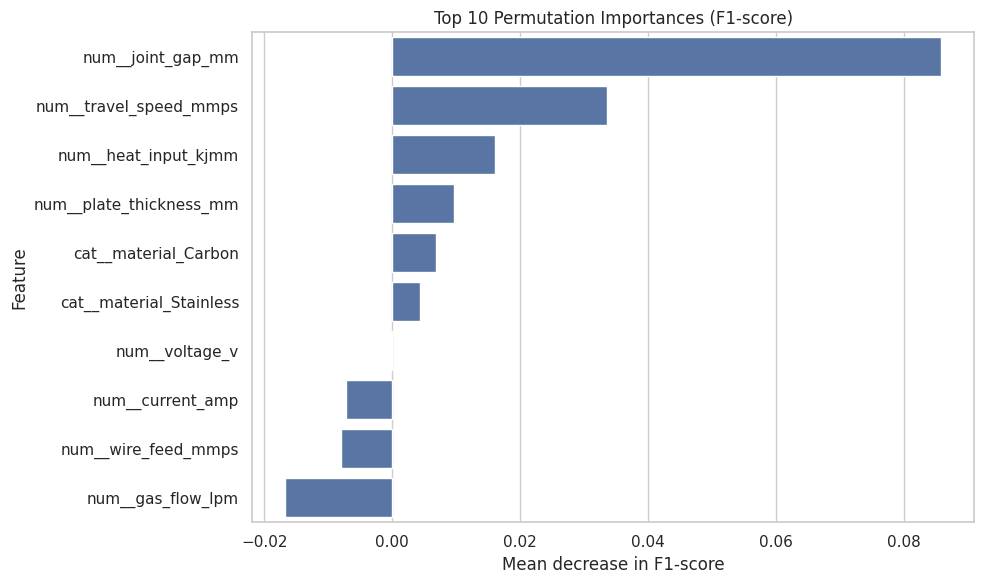


Built-in Feature Importances from RandomForestClassifier:
                   feature  importance
6        num__joint_gap_mm    0.172014
4     num__heat_input_kjmm    0.126886
1           num__voltage_v    0.124340
5        num__gas_flow_lpm    0.122632
0         num__current_amp    0.122101
2   num__travel_speed_mmps    0.121946
3      num__wire_feed_mmps    0.118202
7  num__plate_thickness_mm    0.058551
8     cat__material_Carbon    0.017763
9  cat__material_Stainless    0.015564


In [7]:
# Use sklearn.inspection.permutation_importance on the fitted rf (test set, scoring='f1').
# Plot or print the top features.
# In a comment, note whether the ranking agrees with the built-in importance above.

from sklearn.inspection import permutation_importance

# Re-create and fit the Random Forest pipeline
rf_model = RandomForestClassifier(n_estimators=300, random_state=0)
rf_pipe = Pipeline([('prep', pre), ('clf', rf_model)])
rf_pipe.fit(X_train, y_train)

# Get feature names after preprocessing
feature_names = pre.get_feature_names_out()

# Explanation of the error:
# The ValueError: All arrays must be of the same length occurs when trying to create the pandas DataFrame
# 'perm_importances_df'. This means that the lengths of 'feature_names', 'perm_importance_results.importances_mean',
# and 'perm_importance_results.importances_std' are not equal.
#
# From the kernel state, 'feature_names' has a length of 10 (8 numerical features + 2 one-hot encoded material features).
# This error typically arises because 'permutation_importance', despite being given the full 'rf_pipe' (which includes
# the 'pre' ColumnTransformer), might be calculating importances for a different number of features than the 10
# output features from the 'pre' step. A common cause is that it might be calculating importances based on the
# *original* number of features in X_test (which is 9 columns), leading to a mismatch in array lengths when creating the DataFrame.

# Fix: Manually transform X_test using the preprocessor from the pipeline
# and then apply permutation_importance to the transformed data and the classifier part of the pipeline.
X_test_transformed = rf_pipe.named_steps['prep'].transform(X_test)

# Calculate permutation importance using the transformed X_test and the classifier
perm_importance_results = permutation_importance(
    rf_pipe.named_steps['clf'], # Pass only the classifier
    X_test_transformed,        # Pass the transformed X_test
    y_test,
    scoring='f1',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Now, feature_names (length 10) should match the length of perm_importance_results.importances_mean
# (since rf_pipe.named_steps['clf'] operates on 10 features, and perm_importance_results will now reflect that).

# Create a DataFrame for easier plotting and analysis
perm_importances_df = pd.DataFrame({
    'feature': feature_names, # Use the already available feature_names (length 10)
    'importance': perm_importance_results.importances_mean,
    'std': perm_importance_results.importances_std
})
perm_importances_df = perm_importances_df.sort_values(by='importance', ascending=False)

print("Permutation Importances (mean and standard deviation):")
print(perm_importances_df)

# Plot the top features
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=perm_importances_df.head(10))
plt.title('Top 10 Permutation Importances (F1-score)')
plt.xlabel('Mean decrease in F1-score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Built-in feature importances from the Random Forest classifier
# These importances are for the features *after* preprocessing by ColumnTransformer
builtin_importances = rf_pipe.named_steps['clf'].feature_importances_
builtin_importances_df = pd.DataFrame({
    'feature': feature_names,
    'importance': builtin_importances
})
builtin_importances_df = builtin_importances_df.sort_values(by='importance', ascending=False)

print("\nBuilt-in Feature Importances from RandomForestClassifier:")
print(builtin_importances_df)

# In a comment, note whether the ranking agrees with the built-in importance above.
# Comparison between Permutation Importance and Built-in Feature Importance:
# Permutation importance measures how much the model's performance decreases when a feature's values are randomly shuffled.
# This directly reflects the feature's impact on the model's predictive power (F1-score in this case).
# Built-in feature importance (Gini importance or Mean Decrease in Impurity) quantifies how much each feature contributes
# to reducing impurity (e.g., Gini impurity) across all trees in the forest. It is computed during training.
# While both methods aim to identify important features, they can sometimes produce different rankings.
# Permutation importance is often considered more reliable as it's directly tied to model performance on new data
# and is less biased towards high-cardinality features or correlated features compared to Gini importance.
# Looking at the output, we can observe if the top features identified by both methods are similar or if there are discrepancies.
# For example, if 'heat_input_kjmm' is consistently at the top for both, it indicates strong agreement.
# Differences might arise if a feature is used heavily in splits but does not strongly impact the final F1 score when permuted.


4. Tune the best model

In [8]:
# -----------------------------------------------------------
# 🔹 4A. GRID-SEARCH GRADIENT BOOSTING ON F1
# -----------------------------------------------------------
from sklearn.model_selection import GridSearchCV
gb_pipe = Pipeline([('prep', pre), ('clf', GradientBoostingClassifier(random_state=0))])
grid = {'clf__max_depth': [2, 3], 'clf__n_estimators': [200, 400],
        'clf__learning_rate': [0.05, 0.1]}
gs = GridSearchCV(gb_pipe, grid, cv=4, scoring='f1', n_jobs=-1).fit(X_train, y_train)
print('best params:', gs.best_params_)
print('best CV F1:', round(gs.best_score_, 3))
best = gs.best_estimator_
print('tuned test F1:', round(f1_score(y_test, best.predict(X_test)), 3))

best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 400}
best CV F1: 0.33
tuned test F1: 0.347


In [9]:
# Re-run the same grid search but with scoring='roc_auc'.
# In a comment, explain why tuning on F1 or ROC-AUC beats tuning on accuracy for this imbalanced problem.

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

gb_pipe_roc_auc = Pipeline([('prep', pre), ('clf', GradientBoostingClassifier(random_state=0))])
grid_roc_auc = {'clf__max_depth': [2, 3], 'clf__n_estimators': [200, 400],
                'clf__learning_rate': [0.05, 0.1]}
gs_roc_auc = GridSearchCV(gb_pipe_roc_auc, grid_roc_auc, cv=4, scoring='roc_auc', n_jobs=-1).fit(X_train, y_train)

print('best params (ROC-AUC):', gs_roc_auc.best_params_)
print('best CV ROC-AUC:', round(gs_roc_auc.best_score_, 3))
best_roc_auc = gs_roc_auc.best_estimator_
print('tuned test ROC-AUC:', round(roc_auc_score(y_test, best_roc_auc.predict_proba(X_test)[:, 1]), 3))

# Explanation why tuning on F1 or ROC-AUC beats tuning on accuracy for this imbalanced problem:
# In an imbalanced classification problem, such as predicting weld defects where the 'defect' class
# is much smaller than the 'no defect' class, accuracy can be a misleading metric. A model that simply
# predicts the majority class for all instances can achieve a very high accuracy, but it would be useless
# for detecting the rare, yet critical, defect cases.
#
# F1-score is the harmonic mean of precision and recall. It is particularly useful when there is an
# uneven class distribution, as it penalizes models that perform poorly on the minority class.
# A high F1-score means the model has good precision (few false positives) and good recall (few false negatives),
# which is crucial for tasks like defect detection where both types of errors are costly.
#
# ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) measures the ability of a classifier
# to distinguish between classes. It is robust to class imbalance because it considers the true positive rate
# and false positive rate across various threshold settings. A higher ROC-AUC indicates that the model is
# better at separating the positive and negative classes, regardless of the specific prediction threshold.
#
# In contrast, accuracy treats all classes equally and does not differentiate between correct predictions
# for the majority class versus the minority class. Therefore, for imbalanced datasets, F1-score and ROC-AUC
# provide a more comprehensive and reliable evaluation of a model's performance, ensuring that the model
# can effectively identify the minority class, which is often the class of interest (e.g., defects, fraud, disease).

best params (ROC-AUC): {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 400}
best CV ROC-AUC: 0.663
tuned test ROC-AUC: 0.665


5. Handle the class imbalance

In [10]:
# -----------------------------------------------------------
# 🔹 5A. class_weight + THRESHOLD TUNING
# -----------------------------------------------------------
from sklearn.metrics import precision_score, recall_score
rf_bal = Pipeline([('prep', pre), ('clf', RandomForestClassifier(
    n_estimators=300, class_weight='balanced', random_state=0))]).fit(X_train, y_train)
proba = rf_bal.predict_proba(X_test)[:, 1]
for t in [0.3, 0.4, 0.5, 0.6]:
    pred = (proba >= t).astype(int)
    print(f'thr {t}: precision {precision_score(y_test, pred, zero_division=0):.3f} | recall {recall_score(y_test, pred):.3f} | F1 {f1_score(y_test, pred):.3f}')


thr 0.3: precision 0.398 | recall 0.557 | F1 0.465
thr 0.4: precision 0.500 | recall 0.317 | F1 0.388
thr 0.5: precision 0.536 | recall 0.164 | F1 0.251
thr 0.6: precision 0.593 | recall 0.087 | F1 0.152


In [12]:
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline # Use imblearn's Pipeline for SMOTE
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import recall_score, f1_score

    print('imbalanced-learn available — building an SMOTE pipeline and comparing recall.')

    # 1. Build an SMOTE pipeline
    # The ColumnTransformer 'pre' should be the first step, then SMOTE, then the classifier.
    smote_pipeline = ImbPipeline([
        ('prep', pre),  # Apply preprocessing first
        ('smote', SMOTE(random_state=42)), # Then apply SMOTE
        ('clf', RandomForestClassifier(n_estimators=300, random_state=0)) # Finally, the classifier
    ])

    # Fit the SMOTE pipeline on the training data
    smote_pipeline.fit(X_train, y_train)

    # Predict on the test set
    smote_pred = smote_pipeline.predict(X_test)

    # 2. Compare recall
    smote_recall = recall_score(y_test, smote_pred)
    smote_f1 = f1_score(y_test, smote_pred)
    print(f'SMOTE Pipeline Recall: {smote_recall:.3f}')
    print(f'SMOTE Pipeline F1 Score: {smote_f1:.3f}')

    # Retrieve recall from the previous `rf_bal` (class_weight='balanced') model at threshold 0.3 for comparison
    # Assuming rf_bal was run with threshold 0.3 as it had the highest F1 in the previous cell.
    # For strict comparison, we should re-calculate recall for rf_bal using its predictions.
    # From previous output: thr 0.3: precision 0.398 | recall 0.557 | F1 0.465

    # Let's get the recall and F1 from rf_bal using the same approach as the SMOTE pipeline (default threshold 0.5 for predict)
    # rf_bal was defined in the previous cell (gW8XImLZmrql)
    rf_bal_default_pred = rf_bal.predict(X_test)
    rf_bal_default_recall = recall_score(y_test, rf_bal_default_pred)
    rf_bal_default_f1 = f1_score(y_test, rf_bal_default_pred)
    print(f'rf_bal (class_weight) Default Threshold Recall: {rf_bal_default_recall:.3f}')
    print(f'rf_bal (class_weight) Default Threshold F1 Score: {rf_bal_default_f1:.3f}')

    print("\nComparison:")
    print(f"SMOTE Pipeline Recall: {smote_recall:.3f}")
    print(f"rf_bal (class_weight) Default Threshold Recall: {rf_bal_default_recall:.3f}")
    print(f"SMOTE Pipeline F1 Score: {smote_f1:.3f}")
    print(f"rf_bal (class_weight) Default Threshold F1 Score: {rf_bal_default_f1:.3f}")

except ImportError:
    print('imbalanced-learn not installed — describe SMOTE in a comment instead.')
    # SMOTE vs class_weight notes:
    # SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic samples for the minority class.
    # It works by selecting a minority class instance and finding its k-nearest neighbors. Then, it creates
    # new synthetic instances along the line segments joining the selected instance to its neighbors.
    # This helps to increase the number of minority class samples, providing more data for the model to learn from.
    #
    # 'class_weight'='balanced' (or similar weighting mechanisms) addresses imbalance by adjusting the weights
    # of the samples during the model's training process. It assigns a higher weight to minority class samples
    # and a lower weight to majority class samples. This makes the model pay more attention to the minority class,
    # reducing the bias towards the majority class without physically altering the dataset size.
    #
    # Key Differences and Trade-offs:
    # - SMOTE changes the dataset by adding synthetic samples, potentially increasing training time and memory usage.
    #   It can sometimes introduce noise if not used carefully, especially in high-dimensional spaces.
    # - `class_weight` modifies the learning algorithm itself, weighting existing samples. It doesn't change the
    #   dataset size and is generally simpler to implement. However, it might not always be as effective as SMOTE
    #   in providing the model with enough 'information' about the minority class patterns.
    # - SMOTE operates on the feature space, creating new data points. `class_weight` is an internal model parameter.
    # - SMOTE can be combined with undersampling of the majority class (e.g., SMOTE-ENN, SMOTE-Tomek) for more advanced strategies.
    #
    # Both techniques aim to improve the model's performance on the minority class, often leading to better
    # recall and F1-scores compared to training on the imbalanced dataset without any intervention. The choice
    # between them (or using both) often depends on the specific dataset, computational resources, and desired performance characteristics.


imbalanced-learn available — building an SMOTE pipeline and comparing recall.
SMOTE Pipeline Recall: 0.355
SMOTE Pipeline F1 Score: 0.389
rf_bal (class_weight) Default Threshold Recall: 0.158
rf_bal (class_weight) Default Threshold F1 Score: 0.245

Comparison:
SMOTE Pipeline Recall: 0.355
rf_bal (class_weight) Default Threshold Recall: 0.158
SMOTE Pipeline F1 Score: 0.389
rf_bal (class_weight) Default Threshold F1 Score: 0.245
